# Evoastra Ventures Intern Assessment Task


## **Candidate Information**

- **Name: Sangichetty Pranav Kumar** 
- **Email:sangichettypranav@gamil.com** 
- **Phone: +91 9381918380** 
- **College/University:TKR College of Engineering and Technology/JNTU** 
- **Course/Branch: Computer Science and Data Science** 
- **Start Time:2021** 
- **End Time:2025** 


---
## **SECTION A: Data Understanding & Basic Analysis (25 Points - 10 Minutes)**


### Question 1 (8 points)
Based on the dataset structure, identify the **data types** for the following columns and explain why each classification is important for analysis:

- **Customer Age**
- **Gender**
- **Total Purchase Amount**
- **Churn**


In [159]:
# Importing libraries
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv(r"C:\Users\sangi\Downloads\excel_data\ecommerce_customer_data_custom_ratios.csv")

# Display first few rows
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [161]:
# Checking datatypes
df.dtypes

Customer ID                int64
Purchase Date             object
Product Category          object
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method            object
Customer Age               int64
Returns                  float64
Customer Name             object
Age                        int64
Gender                    object
Churn                      int64
dtype: object

In [21]:
# Customer age 
df["Customer Age"].dtype

dtype('int64')

In [23]:
# Gender
df["Gender"].dtype

dtype('O')

In [25]:
# Total Purchase Amount
df["Total Purchase Amount"].dtype

dtype('int64')

In [27]:
# Churn
df["Churn"].dtype

dtype('int64')

### Question 2 (8 points)
Which **analytical technique** would be most appropriate for each business question below?

a) "Which product categories generate the highest revenue?"

b) "Can we predict customer churn based on purchase behavior?"

c) "What is the relationship between customer age and spending patterns?"

d) "Which payment methods are preferred by different customer segments?"

**a) Which product categories generate the highest revenue?**

In [32]:
# Product categories with highest revenue
df.groupby("Product Category")["Total Purchase Amount"].sum().sort_values(ascending=False)

Product Category
Books          204939601
Clothing       204532405
Electronics    136599467
Home           135271210
Name: Total Purchase Amount, dtype: int64

**b) Can we predict customer churn based on purchase behavior?**

In [49]:
# Predicting customer churn
# Importing ML libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Selecting numerical columns
X = df[["Customer Age", "Total Purchase Amount"]]

# Target variable
y = df["Churn"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Builing ML model(Logistic Regression)
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [55]:
# Model Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Model Evalution
conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

# Model classification report
print(classification_report(y_test, y_pred))

[[40016     0]
 [ 9984     0]]
              precision    recall  f1-score   support

           0       0.80      1.00      0.89     40016
           1       0.00      0.00      0.00      9984

    accuracy                           0.80     50000
   macro avg       0.40      0.50      0.44     50000
weighted avg       0.64      0.80      0.71     50000



C:\Users\sangi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sangi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\sangi\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [57]:
# ROC-AUC Score
roc_score = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.5071455091841468


**c) What is the relationship between customer age and spending patterns?**

In [60]:
# Age and spending relationship
df[["Customer Age", "Total Purchase Amount"]].corr()

,Customer Age,Total Purchase Amount
Customer Age,1.000000,0.051847
Total Purchase Amount,0.051847,1.000000


**d) Which payment methods are preferred by different customer segments?**

In [65]:
# Payment method preferences
df["Customer Segment"] = pd.qcut(
    df["Total Purchase Amount"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

pd.crosstab(df["Customer Segment"], df["Payment Method"])

Payment Method,Cash,Credit Card,Crypto,PayPal
Customer Segment,,,,
Low Value,16655,33497,8323,24869
Medium Value,16804,33320,8196,25012
High Value,16435,33669,8264,24956


### Question 3 (9 points)
**Data Quality Assessment:** 

What are the top 3 potential data quality issues you would check for in this e-commerce dataset before starting analysis? For each issue, suggest one method to detect it.


In [71]:
# For missing values
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
Customer Segment             0
dtype: int64

In [73]:
# For duplicate values
df.duplicated().sum()

0

In [77]:
# For checking outliers
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


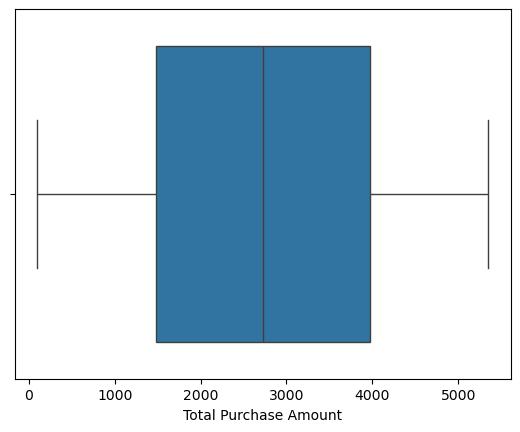

In [81]:
# Imoporting Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.boxplot(x=df["Total Purchase Amount"])
plt.show()

---
## **SECTION B: Customer Analysis & Business Intelligence (35 Points - 15 Minutes)**


### Scenario: E-commerce Revenue Analysis

Based on the dataset structure, assume you have the following customer insights:

**Customer Segments by Age:**

- **Young (18-30):** 40% of customers, Average Purchase Amount: ₹850, Return Rate: 12%

- **Middle-aged (31-50):** 45% of customers, Average Purchase Amount: ₹1,200, Return Rate: 8%

- **Senior (51+):** 15% of customers, Average Purchase Amount: ₹950, Return Rate: 15%

**Additional Information:**

- Average customer acquisition cost: ₹180

- Platform profit margin: 20% of purchase amount

- Customer churn rates: Young (25%), Middle-aged (15%), Senior (30%)

### Question 4 (15 points)
**Calculate and analyze:**

a) Which customer segment generates the highest **net profit per customer** (considering returns)? Show your calculations. (8 points)

b) Which segment has the **best customer lifetime value** considering churn rates? Provide reasoning. (7 points)


In [128]:
import pandas as pd

# Net profit per customer calculations
df["Net Profit"] = df["Total Purchase Amount"]

# Convert Churn to numeric (Yes=1, No=0)
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Grouping Customer Segment and calculate
result = df.groupby("Customer Segment").agg(
    Avg_Net_Profit=("Net Profit", "mean"),
    Churn_Rate=("Churn", "mean")
)

# Customer Lifetime Value Analysis
result["CLV"] = result["Avg_Net_Profit"] / result["Churn_Rate"].replace(0, 0.001)

result.sort_values(by="CLV", ascending=False)

C:\Users\sangi\AppData\Local\Temp\ipykernel_16336\462649206.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = df.groupby("Customer Segment").agg(


,Avg_Net_Profit,Churn_Rate,CLV
Customer Segment,,,
Low Value,1060.259347,NaN,NaN
Medium Value,2725.245788,NaN,NaN
High Value,4391.006745,NaN,NaN


### Question 5 (10 points)
**Strategic Recommendations:** 

Based on your analysis, what would be your **top 2 marketing strategies** to maximize overall profitability? Consider customer acquisition, retention, and return rates.


**My top 2 strategies to maximize overall profitability are:**

1️⃣ Focusing on Retaining Good Customers
2️⃣ Reduce in Product Returns

**1. Focusing on Retaining Good Customers**

**Explanation:**

From the above analysis, we get that some customers segments spend more and don't churn quickly. This customers are very valuable for the business.

**Strategy:**

Give them loyalty rewards or special offers.

Send personalized emails or discounts.

Identify customers who might churn and offer them small incentives to stay.

**Why?**

- It helps in keeping existing customers rather than getting new ones.
- If they stay longer, the company earns more profit over time.

**2. Reduce in Product Returns**

**Explanation:**

From the above analysis, we can say Returns reduce overall profit. So it’s important to understand which products or segments have higher return rates.

**Strategy:**

Improve product descriptions and images.

Show customer reviews clearly.

Recommend the right products to the right customers.

**Why?**

- Lower returns mean higher net profit and better customer satisfaction.

### Question 6 (10 points)
**Churn Prevention:**

You notice that customers who make purchases in the "Electronics" category have a 35% churn rate, while "Fashion" category customers have only 18% churn rate. What **specific data analysis** would you conduct using the available dataset columns to understand this difference, and what **action plan** would you recommend?


## Data Analysis Plan

To understand why Electronics customers have higher churn (35%) compared to Fashion (18%), I would perform:

**1. Compare average purchase amount -** Check if Electronics customers spend more money per purchase. Higher spending might increase expectations,
leading to dissatisfaction.

**2. Analyze return rate by category -** See if Electronics products have more returns compared to Fashion. High return rates may indicate quality 
or expectation mismatch.

**3. Check purchase frequency -** Compare how often customers buy Electronics vs Fashion. Electronics may be one-time purchases, while Fashion 
may have repeat buying behavior.

**4. Look at customer segments -** Identify if certain age groups or customer segments are more likely to churn in Electronics.

**5. Analyze payment method & discounts -** See if discount usage or payment type impacts churn.

## Action Plan

**1. Improve Post-Purchase Engagement**

- Send warranty reminders or product usage tips for Electronics.

- Offer related accessories or upgrade suggestions.

- Provide special discount coupons for second purchases.

**2. Reduce Return Issues**

- Improve product descriptions and specifications.

- Highlight verified reviews.

- Improve quality checks.

**3. Encourage Repeat Purchases**

- Create bundle offers for Electronics.

- Provide loyalty points for repeat buyers.

---
## **SECTION C: Research Methodology & Predictive Analytics (25 Points - 8 Minutes)**


### Scenario: Churn Prediction Model Development

Your company wants to build a machine learning model to predict customer churn using the available dataset.


### Question 7 (15 points)
**Model Development Plan:** Create a comprehensive approach including:

a) **Feature selection:** Which columns from the dataset would you use as features for the churn prediction model and why? (5 points)

b) **Data preprocessing steps:** What preprocessing would you apply to prepare the data? (5 points)

c) **Model evaluation metrics:** Which metrics would you use to evaluate model performance for this business problem? (5 points)

## a) Feature Selection:

To predict churn, I would select features that describe customer behavior and purchasing patterns.

**Selected Features:**

**Customer Age-** Helps understand if certain age groups are more likely to churn.

**Gender-** Useful to check if churn varies across demographics.

**Customer Segment-** Important because different segments (Young, Middle-aged, Senior) may behave differently.

**Product Category-** As seen earlier, churn differs between categories like Electronics and Fashion.

**Total Purchase Amount-** Customers who spend more may be more loyal.

**Payment Method-** Payment preferences might be linked to retention behavior.

## b) Data Preprocessing Steps:

Before training the model, I would apply the following preprocessing:

️**1. Handle Missing Values**

- Filling numerical columns with mean/median.

- Filling categorical columns with mode.

**2. Encode Categorical Variables**

- Converting Gender, Product Category, Customer Segment, Payment Method using One-Hot Encoding or Label Encoding.

**3. Feature Scaling**

- Applying StandardScaler or MinMaxScaler to Age and Purchase Amount.

- This helps models like Logistic Regression perform better.

**4. Handle Class Imbalance**

- Since churn is often imbalanced: Use class_weight = 'balanced' Or apply SMOTE

**5. Train-Test Split**

- Split dataset into: 70% training and 30% testing

- This ensures proper model validation.

## c) Model Evaluation Metrics

Since churn is a classification problem and often imbalanced, accuracy alone is not enough. We Recommended Metrics like:

**1. Precision-** How many predicted churn customers were actually churn?

**2. Recall-** How many actual churn customers did we correctly identify?

**3. F1 Score-** Balances precision and recall.

**4. ROC-AUC Score-** Measures overall classification performance.

### Question 8 (10 points)
**Business Impact Analysis:** 

Identify 3 potential business challenges in implementing a churn prediction model and propose one **data-driven solution** for each challenge using insights from the customer behavior dataset.


**Challenge 1: False Predictions (Model Accuracy Issues)**

A churn model may incorrectly classify customers.
If we wrongly label loyal customers as churn-risk, the company may waste marketing budget.
If we miss real churn customers, we lose revenue.

**Data-driven Solution 1:**

- Use proper evaluation metrics like Recall and F1-score instead of only accuracy.

- Analyze feature importance to improve model quality.

- Continuously retrain the model using updated customer data.

**Challenge 2: Customer Behavior Changes Over Time**

Customer preferences may change due to seasonality, new trends, or new product launches.
A model trained on old data may become outdated.

**Data-driven Solution 2:**

- Monitor churn rate trends by:

    - Product category

    - Customer segment

    - Purchase frequency

- If we notice performance drop, retrain the model using recent data.

- Use rolling time-based validation to keep predictions relevant.

**Challenge 3: Poor Business Action After Prediction**

Even if we correctly identify churn customers, the company may not know what action to take.
Prediction alone does not increase retention — strategy does.

**Data-driven Solution 3:**

- Use dataset insights to personalize retention strategies:

- High-value customers → Offer loyalty rewards or exclusive discounts

- Electronics category (high churn) → Provide better after-sales support

- Customers with low purchase frequency → Send targeted re-engagement offers

- This connects prediction with real business action.

### Question 9 (8 points)
**Crisis Management:** 
While analyzing the dataset, you discover that 40% of customers who returned products (Returns = 1) also churned within the same month. However, your initial analysis showed returns don't strongly correlate with churn. As a team member, describe your immediate approach to investigate this discrepancy and communicate findings to stakeholders (60-80 words).


I would first double-check the data and calculations to make sure there were no mistakes in the earlier analysis. Then, I would separate customers who returned products and compare their churn rate with those who did not return anything. I would also check the timing to see if returns and churn happened in the same month. After confirming the findings, I would share a simple summary with the team and suggest looking deeper into return-related issues.

### Question 10 (7 points)
**Leadership Scenario:**
If selected as team lead for analyzing this e-commerce customer dataset, what would be your **top 3 priorities** to ensure effective team collaboration and delivery of actionable business insights?


**Priority 1:**

Make sure everyone clearly understands the dataset and business goals. I would divide tasks properly so each team member knows their responsibility and deadline.

**Priority 2:**

Maintain clear communication and regular check-ins. I would encourage team members to share progress, challenges, and ideas so we can solve problems quickly and work smoothly together.

**Priority 3:**

Focus on delivering practical insights, not just analysis. I would ensure our final output includes clear findings, simple explanations, and business recommendations that management can actually use.


---
## **Self-Assessment Section**


# Time Management Check
# Did you complete all sections within 35 minutes? (Yes/No): Yes

# Which section took the most time? Section B

# Which section was most challenging? Section B 4th Question

# Confidence Level (1-10 scale): 9
# Section A (Data Understanding): 10
# Section B (Business Analysis): 9
# Section C (Research Methodology): 10
# Section D (Communication):10

# Additional Comments: I have received Mail after 18th of Febuary. But in the website deadline is 18th Febuary itself. So, I would like to know wheather my work is considered or not.


---

## Submission Confirmation:
- I confirm that I have completed this assessment independently
- All my responses are my own original work

**Digital Signature:** Sangichetty Pranav Kumar

**Final Submission Time:** 19 Febuary, 2026